In [1]:
import tensorflow as tf
import os
from Model_Construction import getTime, cutoffs, load_image
import pandas as pd
from tqdm import tqdm
from collections import Counter
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt
import numpy as np
import datetime


image_dir = r"C:\Users\joshy\OneDrive\Documents\Kravitz Lab\freezeData\CNN Data\\"

# permuting fold and cutoff ids

fold_ids = {0 : "0309", 1 : "0322", 2 : "0214", 3 : "0318", 4 : "0506", 5 : "0302"}
# fold_ids = {0 : "0309", 1 : "0302"}

def run_fold(num, set_model=None, AUC=False, num_colors=3, 
IMAGE_SIZE=64):

    if set_model == None:
        model = tf.keras.models.load_model("best_model_fold" + str(num) + "_" + fold_ids[num] + ".keras")
    else:
        model = tf.keras.models.load_model(set_model)

    filelist = [
        os.path.join(image_dir + fold_ids[num] + r'\\', f) 
        for f in os.listdir(image_dir + fold_ids[num] + r'\\')
    ]

    # counts = Counter()

    # bad_times = []

    # for filename in filelist:
    #     _, timestamp, fid = load_test_image(filename)
        # counts[fid] += 1
    #     if fid == -1:
    #             bad_times.append(timestamp)

    # print(min(bad_times))
    # print(max(bad_times))

    # print(counts)

    images = []
    labels = []
    times = []

    for filename in tqdm(filelist, desc=f"Loading {fold_ids[num]}", leave=False):

# Set color number here
    
        img, quality, _, timestamp = load_image(filename, colors=num_colors)
        img = tf.image.convert_image_dtype(
                img,
                tf.float32
            )
        img = tf.image.resize(img, (IMAGE_SIZE, IMAGE_SIZE))
        # if fold_id == num:
        if not AUC:
            images.append(img)
            times.append(timestamp)
        elif AUC:
            if quality != -1:
                images.append(img)
                times.append(timestamp)
                labels.append(quality)
    
    print(f"Fold {num}")
    print(f"Number of images: {len(images)}")


    if images != []:
        test_dataset = (
            tf.data.Dataset
            .from_tensor_slices(tf.stack(images))
            .batch(32)
            .prefetch(tf.data.AUTOTUNE)
        )

        prob_bad = model.predict(test_dataset, verbose=1).flatten()
    else:
        prob_bad = np.array([])

    
    if not AUC:

        nested_list = [times, prob_bad]
        transposed = [list(row) for row in zip(*nested_list)]
    
        df_model = pd.DataFrame(transposed, columns = ['time', 'prob_bad'])
    
        df_model['prob_bad_smooth'] = (
            df_model['prob_bad']
            .rolling(window=25, center=True)
            .mean()
        )

        return df_model
    
    elif AUC:

        quality_val = np.array(labels)

        return quality_val, prob_bad

In [2]:
model_name = 'freezeCNN_mkIV_0318(batchnorm+bright+contrast).keras'
model_names = ['freezeCNN_mkII_0309(96x96_grayscale).keras', 'freezeCNN_mkIII_0309(best)(64x64_RGB).keras', 'freezeCNN_mkVa_0309(decent)(weight_decay+AdamW).keras', 'freezeCNN_mkIV_0318(batchnorm+bright+contrast).keras', 'freezeCNN_mkVb_0506(better)(weight_decay+AdamW).keras']

In [3]:
df_lipschitz = pd.DataFrame()

dfs = []

for key, value in tqdm(fold_ids.items(), desc="Running folds"):
    model_df = run_fold(key, set_model=model_name)
        # model_df['next_prob'] = model_df['prob_bad'].shift(-1)
        # model_df['next_time'] = model_df['time'].shift(-1)
        # for row in model_df.itertuples():
        #     if pd.isna(row.time) or pd.isna(row.next_time):
        #         continue
        #     time_diff = abs(row.time-row.next_time).total_seconds()
        #     val_diff = abs(row.prob_bad-row.next_prob)
        #     l_value = val_diff / time_diff
        #     if time_diff < 600:
        #         df_lipschitz = pd.concat(
        #             [df_lipschitz, 
        #             pd.DataFrame(
        #                 {'time_diff' : [time_diff], 'val_diff' : [val_diff], 'l_value' : [l_value], 'key' : [key]}
        #             )]
        #         )

    dfs += [model_df]

Running folds:   0%|          | 0/6 [00:00<?, ?it/s]

Fold 0
Number of images: 2045
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step


Running folds:  17%|█▋        | 1/6 [00:08<00:42,  8.51s/it]

Fold 1
Number of images: 608
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


Running folds:  33%|███▎      | 2/6 [00:11<00:20,  5.17s/it]

...

Running folds:  67%|██████▋   | 4/6 [00:20<00:09,  4.54s/it]

Fold 4
Number of images: 347
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


Running folds:  83%|████████▎ | 5/6 [00:22<00:03,  3.52s/it]

Fold 5
Number of images: 1018
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


Running folds: 100%|██████████| 6/6 [00:26<00:00,  4.38s/it]


C:\Users\joshy\AppData\Local\Temp\ipykernel_32160\2439768640.py:45: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[0,1].legend()
C:\Users\joshy\AppData\Local\Temp\ipykernel_32160\2439768640.py:64: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


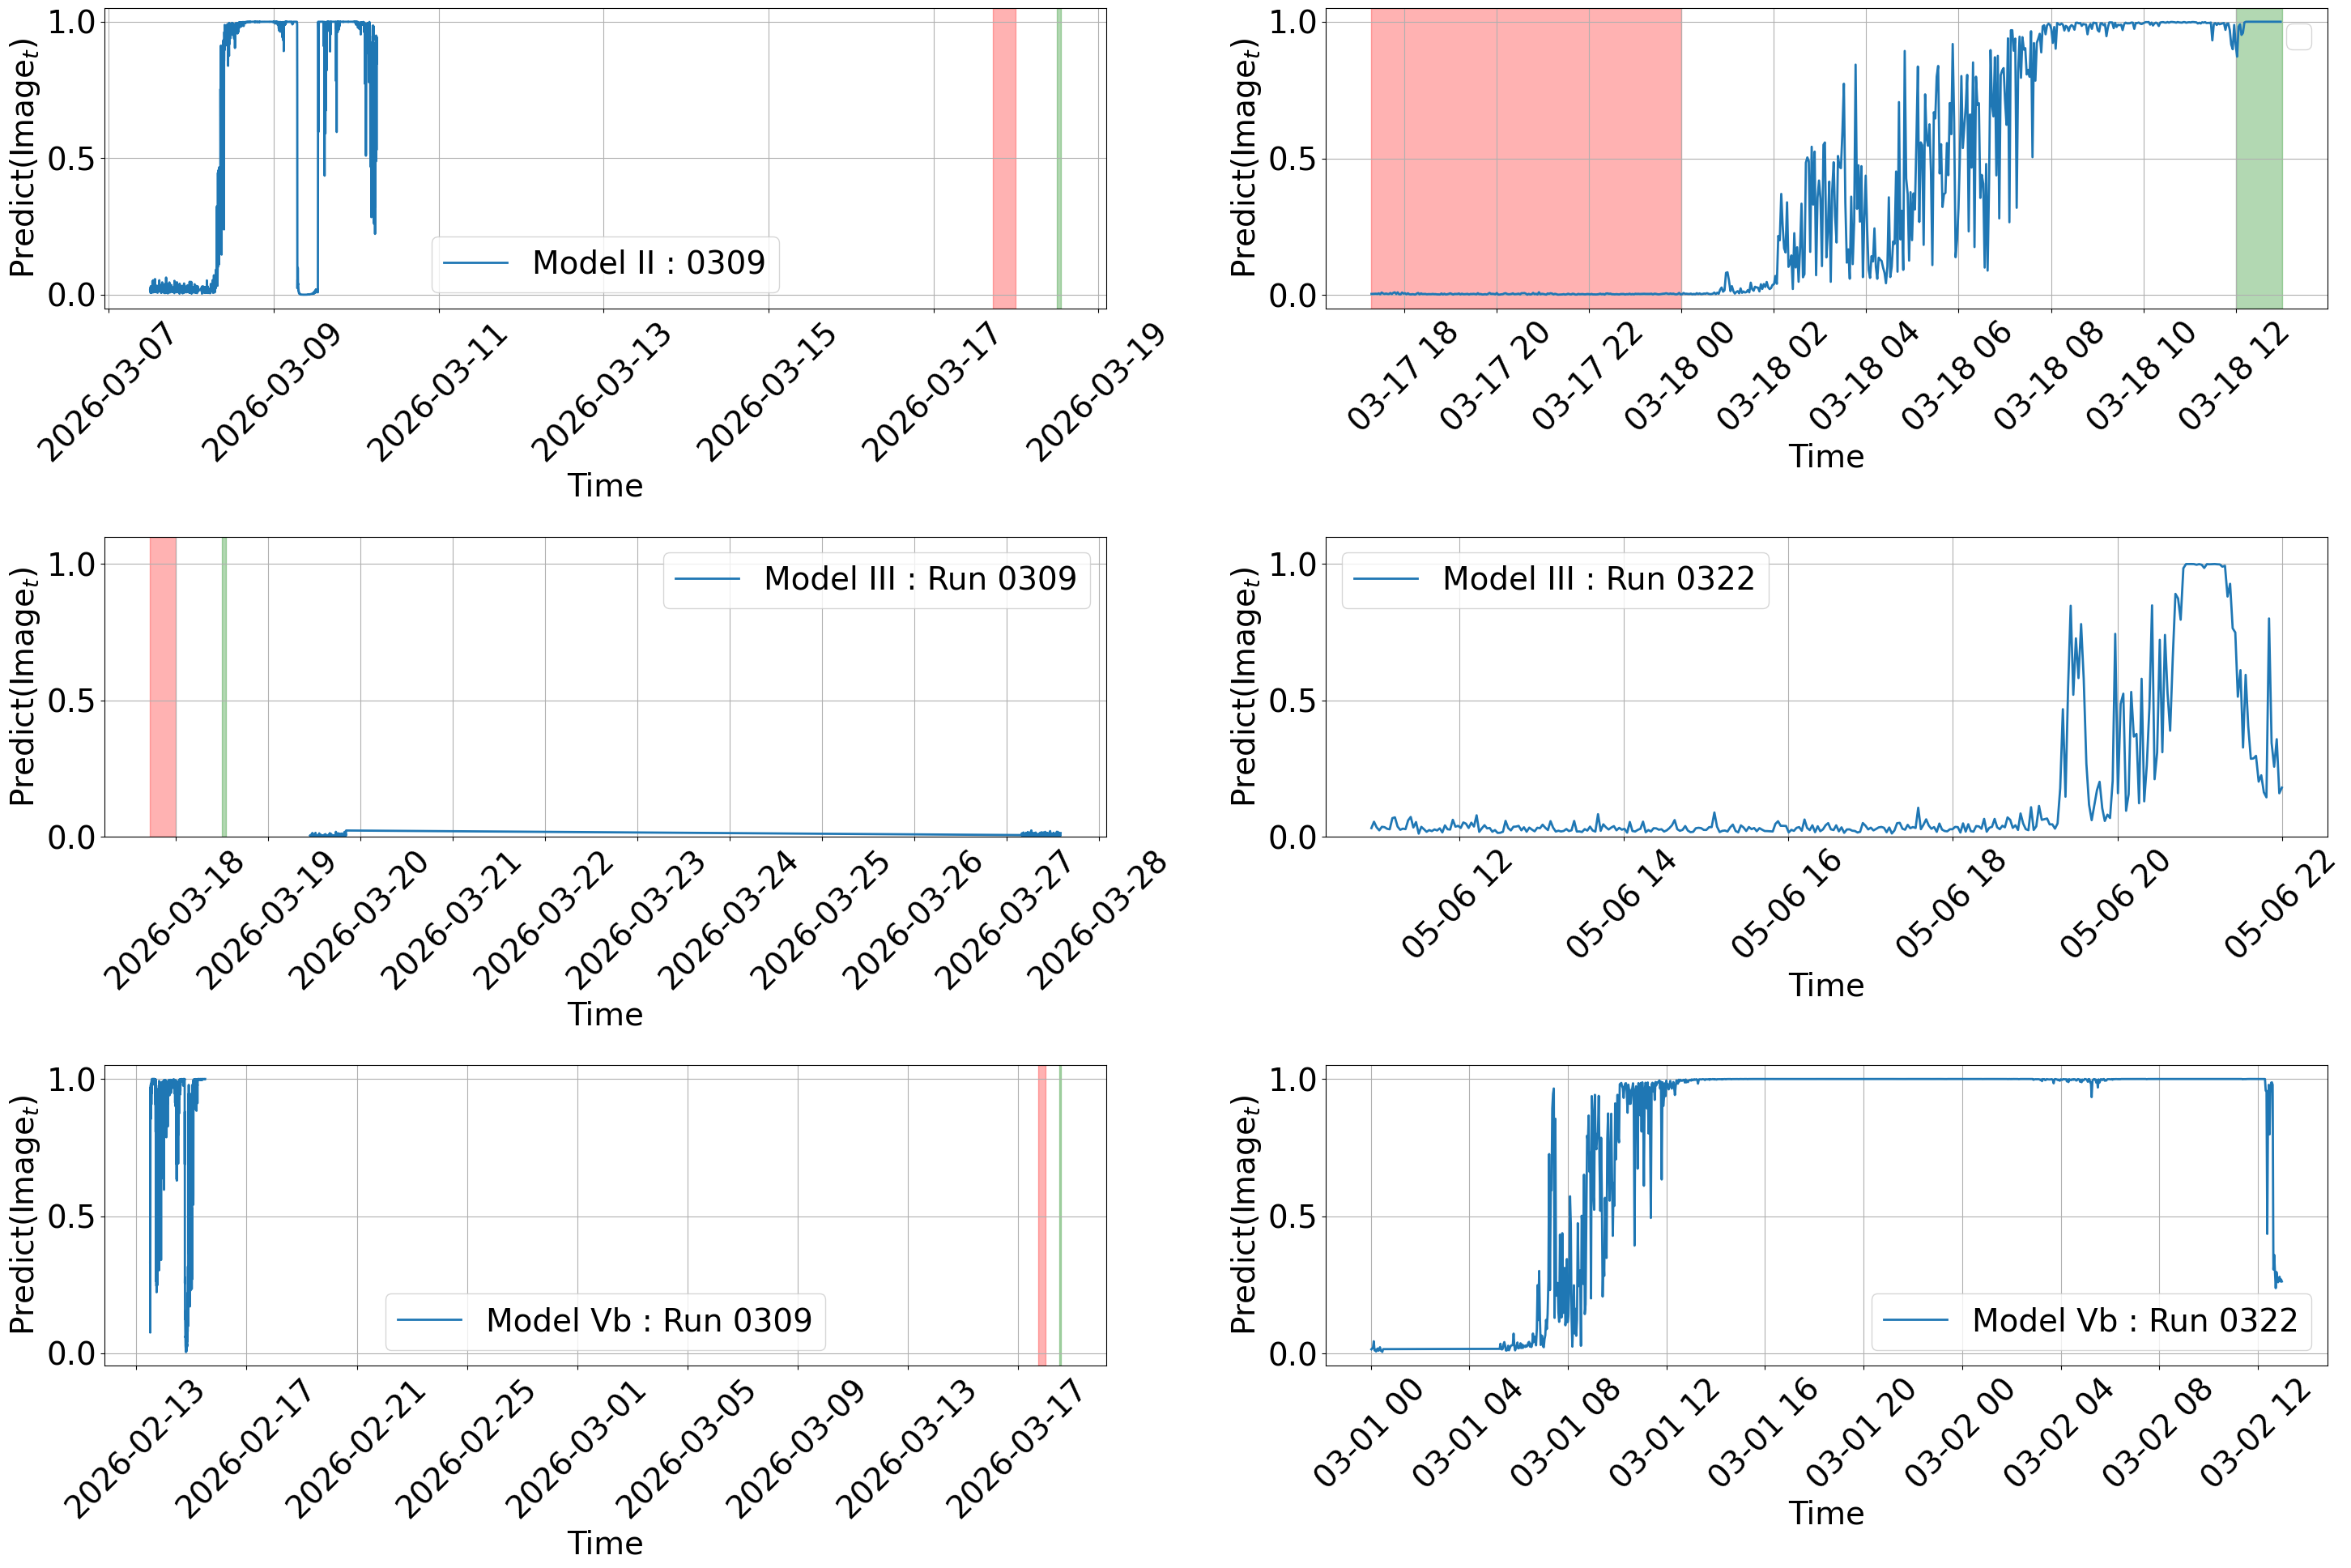

In [5]:
plt.rcParams.update({'font.size': 28})

fig, axs = plt.subplots(3,2, figsize=(30,20))

times = cutoffs[1][1]

axs[0,0].axvspan(times[0], times[1], color='red', alpha=0.3)
axs[0,0].axvspan(times[2], times[3], color='green', alpha=0.3)

axs[1,0].axvspan(times[0], times[1], color='red', alpha=0.3)
axs[1,0].axvspan(times[2], times[3], color='green', alpha=0.3)

axs[2,0].axvspan(times[0], times[1], color='red', alpha=0.3)
axs[2,0].axvspan(times[2], times[3], color='green', alpha=0.3)

axs[0,1].axvspan(times[0], times[1], color='red', alpha=0.3)
axs[0,1].axvspan(times[2], times[3], color='green', alpha=0.3)

for ax in axs.flatten():
    ax.tick_params(axis='x', rotation=45)

sc0 = axs[0,0].plot(dfs[0]['time'], dfs[0]['prob_bad'], linewidth=2, label=f"Model II : {fold_ids[0]}")
axs[0,0].set_ylabel(r"$\text{Predict}(\text{Image}_t)$")
axs[0,0].set_xlabel("Time")
axs[0,0].grid(True)
axs[0,0].legend()

sc1 = axs[1,0].plot(dfs[1]['time'],dfs[1]['prob_bad'], linewidth=2, label=f"Model III : Run {fold_ids[0]}")
axs[1,0].set_ylabel(r"$\text{Predict}(\text{Image}_t)$")
axs[1,0].set_xlabel("Time")
axs[1,0].grid(True)
axs[1,0].set_ylim(0,1.1)
axs[1,0].legend()

sc2 = axs[2,0].plot(dfs[2]['time'],dfs[2]['prob_bad'], linewidth=2, label=f"Model Vb : Run {fold_ids[0]}")
axs[2,0].set_ylabel(r"$\text{Predict}(\text{Image}_t)$")
axs[2,0].set_xlabel("Time")
axs[2,0].grid(True)
axs[2,0].legend()

sc3 = axs[0,1].plot(dfs[3]['time'],dfs[3]['prob_bad'], linewidth=2)  #, label=f"Model IV : Run {fold_ids[3]}")
axs[0,1].set_ylabel(r"$\text{Predict}(\text{Image}_t)$")
axs[0,1].set_xlabel("Time")
axs[0,1].grid(True)
axs[0,1].legend()

sc4 = axs[1,1].plot(dfs[4]['time'],dfs[4]['prob_bad'], linewidth=2, label=f"Model III : Run {fold_ids[1]}")
axs[1,1].set_ylabel(r"$\text{Predict}(\text{Image}_t)$")
axs[1,1].set_xlabel("Time")
axs[1,1].grid(True)
axs[1,1].set_ylim(0,1.1)
axs[1,1].legend()

sc5 = axs[2,1].plot(dfs[5]['time'],dfs[5]['prob_bad'], linewidth=2, label=f"Model Vb : Run {fold_ids[1]}")
axs[2,1].set_ylabel(r"$\text{Predict}(\text{Image}_t)$")
axs[2,1].set_xlabel("Time")
axs[2,1].grid(True)
axs[2,1].legend()

fig.tight_layout()

fig.savefig(f'CNNplotsnew.png')

fig.show()

Fold 0
Number of images: 1945
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


<Figure size 1200x500 with 0 Axes>

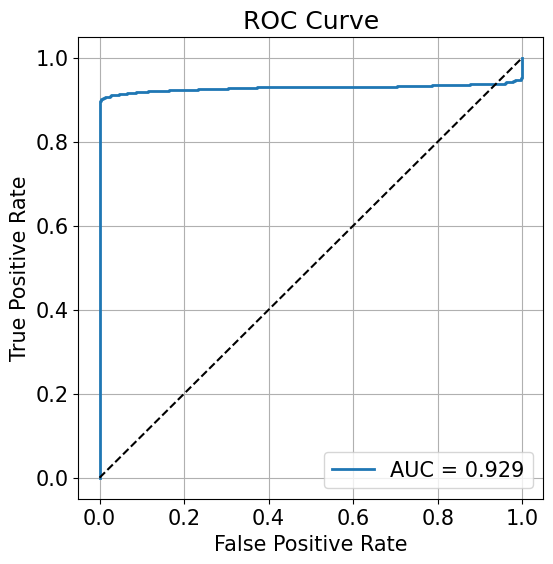

Fold 0
Number of images: 1945
 1/61 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step

61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


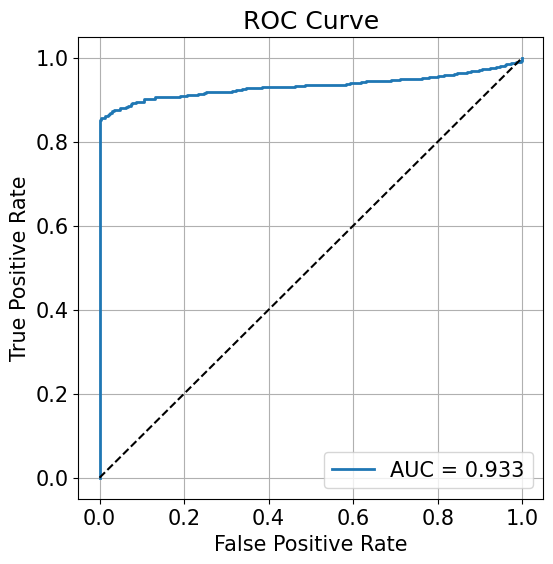

Fold 0
Number of images: 1945
 1/61 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step

61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


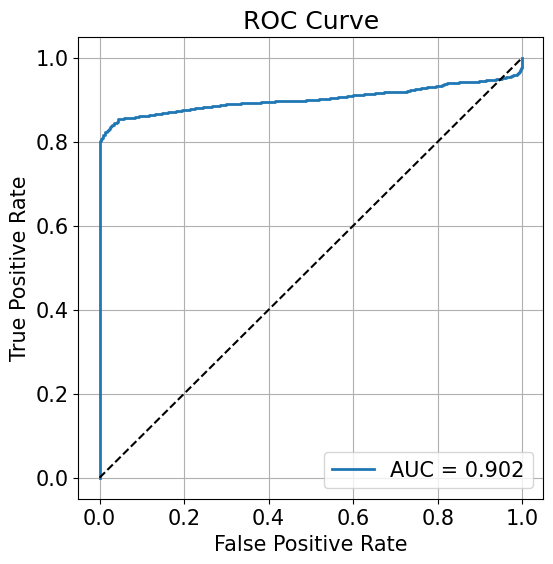

Fold 3
Number of images: 387
 1/13 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step


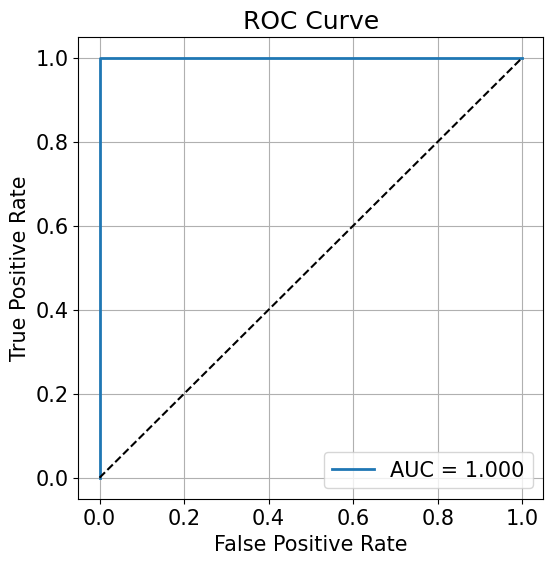

Fold 4
Number of images: 264
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


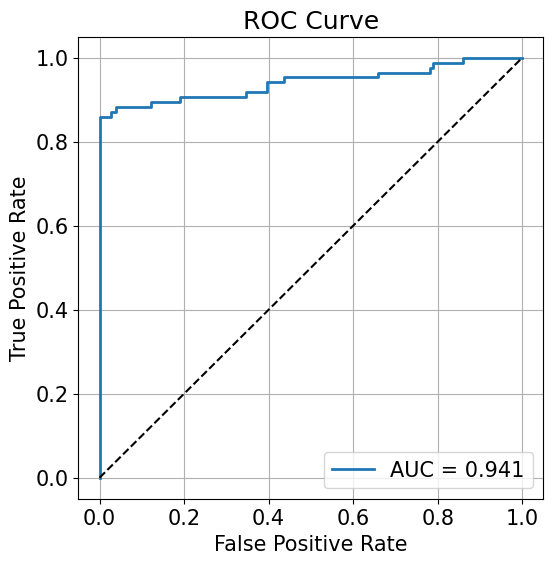

In [14]:
# fold_ids = {0 : "0309", 1 : "0322", 2 : "0214", 3 : "0318", 4 : "0506", 5 : "0302"}
#model_names = ['freezeCNN_mkII_0309(96x96_grayscale).keras', 'freezeCNN_mkIII_0309(best)(64x64_RGB).keras','freezeCNN_mkVb_0506(better)(weight_decay+AdamW).keras']
model_ids = {'freezeCNN_mkII_0309(96x96_grayscale).keras': 0, 'freezeCNN_mkIII_0309(best)(64x64_RGB).keras' : 0, 'freezeCNN_mkIV_0318(batchnorm+bright+contrast).keras' : 3, 'freezeCNN_mkVa_0309(decent)(weight_decay+AdamW).keras' : 0, 'freezeCNN_mkVb_0506(better)(weight_decay+AdamW).keras' : 4}

plt.figure(figsize=(12,5))
plt.rcParams.update({'font.size': 15})

for model_name in model_names:
    
    key = model_ids[model_name]
    if model_name == 'freezeCNN_mkII_0309(96x96_grayscale).keras':
        temp1, temp2 = run_fold(key, set_model=model_name, num_colors=1, IMAGE_SIZE=96, AUC=True)
    else:
        temp1, temp2 = run_fold(key, set_model=model_name, AUC=True)

    y_val = temp1.tolist()
    y_prob = temp2.tolist()

    y_val = np.array(y_val)
    y_prob = np.array(y_prob)

    fpr, tpr, thresholds = roc_curve(y_val, y_prob)
    auc = roc_auc_score(y_val, y_prob)


    plt.figure(figsize=(6,6))

    plt.plot(fpr, tpr, linewidth=2,
    label=f"AUC = {auc:.3f}")

    plt.plot([0,1], [0,1], "k--")

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend(loc="lower right")
    plt.grid(True)

    plt.savefig(f'{model_name}_ROC.png')

    plt.show()




0.9392945080907237 0.806682525743125


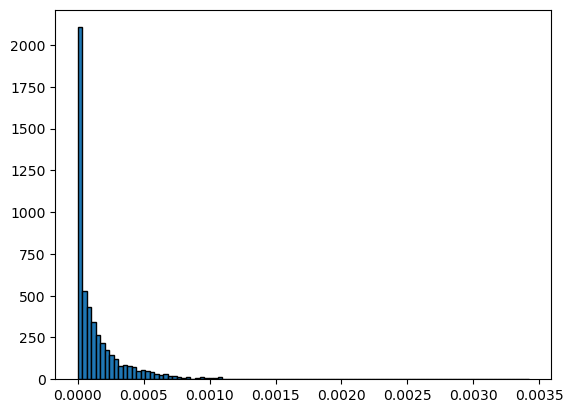

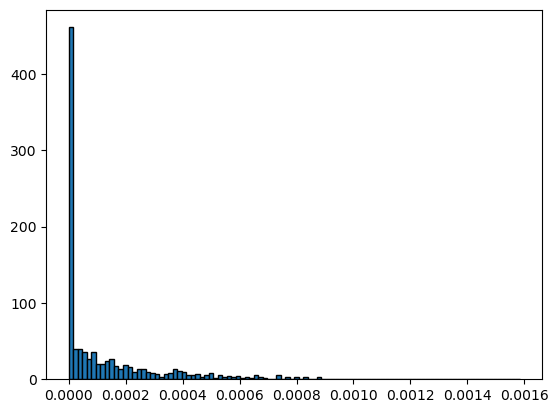

In [33]:
lower_bound = df_lipschitz['l_value'].quantile(0.01)
upper_bound = df_lipschitz['l_value'].quantile(0.99)

df_clean = df_lipschitz[(df_lipschitz['l_value'] >= lower_bound) & (df_lipschitz['l_value'] <= upper_bound)]

max_l = df_clean['l_value'].max()
t_min = df_clean['time_diff'].min()
t_max = df_clean['time_diff'].max()

apr1 = []

apr2 = []

for row in df_lipschitz.itertuples():
    if row.key != 5:
        apr1.append(row.val_diff/row.time_diff)
    else:
        apr2.append(row.val_diff/row.time_diff)

# plt.scatter(
#     df_clean["time_diff"],
#     df_clean["val_diff"]
# )


# plt.axline((0, 0), slope=max_l, color='red', linestyle='--', label=f'L = {max_l}')

# plt.ylabel("Predicted probability of poor freezing")
# plt.xlabel("Time")

# plt.xlim(t_min-1, t_max+1)

# plt.grid(True)

# plt.legend()

print(100*60 * sum(apr1)/len(apr1), 100*60 * sum(apr2)/len(apr2))

plt.hist(apr1, bins=100, edgecolor='black')
plt.show()

plt.hist(apr2, bins=100, edgecolor='black')
plt.show()